Descripcion del problema

El dataset contiene features de audio extraidas por la API de Spotify. Cada fila es una cancion. Los targets son:

    Parte A (binaria): predecir si una cancion es explicit (contiene lenguaje explicito)
    Parte B (multiclase): predecir el genero musical entre pop, rock, hip-hop y classical

Las features de entrada son siempre las mismas 11 columnas numericas: popularity, duration_ms, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo.

## Sección 1

Seccion 1 — Carga y exploracion

Carga el CSV con pd.read_csv(). Revisa el shape y los nulos con .isnull().sum().

Pista: filtra solo las columnas con nulos para no imprimir las 21 filas: df.isnull().sum()[df.isnull().sum() > 0]

### Carga y exploración

#### Importando librerias

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os

d:\FACTORIA_F5\projects\Proyecto8_Peliculas\proyecto8_peliculas_regresion_juanma\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Cargando el archivo

In [2]:
path = kagglehub.dataset_download("melissamonfared/spotify-tracks-attributes-and-popularity")

#df = pd.read_csv(os.path.join(path, "spotify_tracks.csv"))
df = pd.read_csv(os.path.join(path, "dataset.csv"))

print("Shape:", df.shape)

print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (114000, 21)
artists       1
album_name    1
track_name    1
dtype: int64


## Sección 2

Seccion 2 — Limpieza

Elimina las 3 filas con nulos con dropna().

Pista: son solo 3 filas de 114,000. No necesitas estrategia de imputacion, simplemente eliminalas.

### Limpieza

In [3]:
df.dropna(inplace=True)
print('Shape tras limpieza:', df.shape)

Shape tras limpieza: (113999, 21)


## Sección 3

Seccion 3 — Analisis exploratorio

Tres graficos: distribucion de explicit, histogramas de las features, y boxplots agrupados por explicit.

Pista: para los boxplots usa df.boxplot(column=col, by='explicit', ax=ax). El argumento by agrupa automaticamente.

### Análisis exploratorio

In [4]:
import matplotlib.pyplot as plt

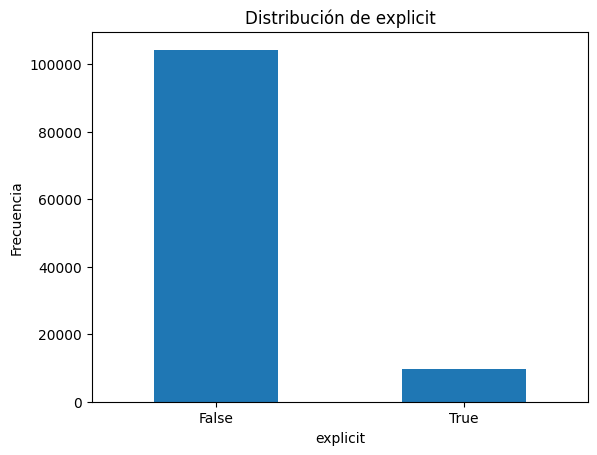

In [5]:
# Gráfico de distribución de la variable explicit
df['explicit'].value_counts().plot(kind='bar', title='Distribución de explicit')
plt.xlabel('explicit')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()

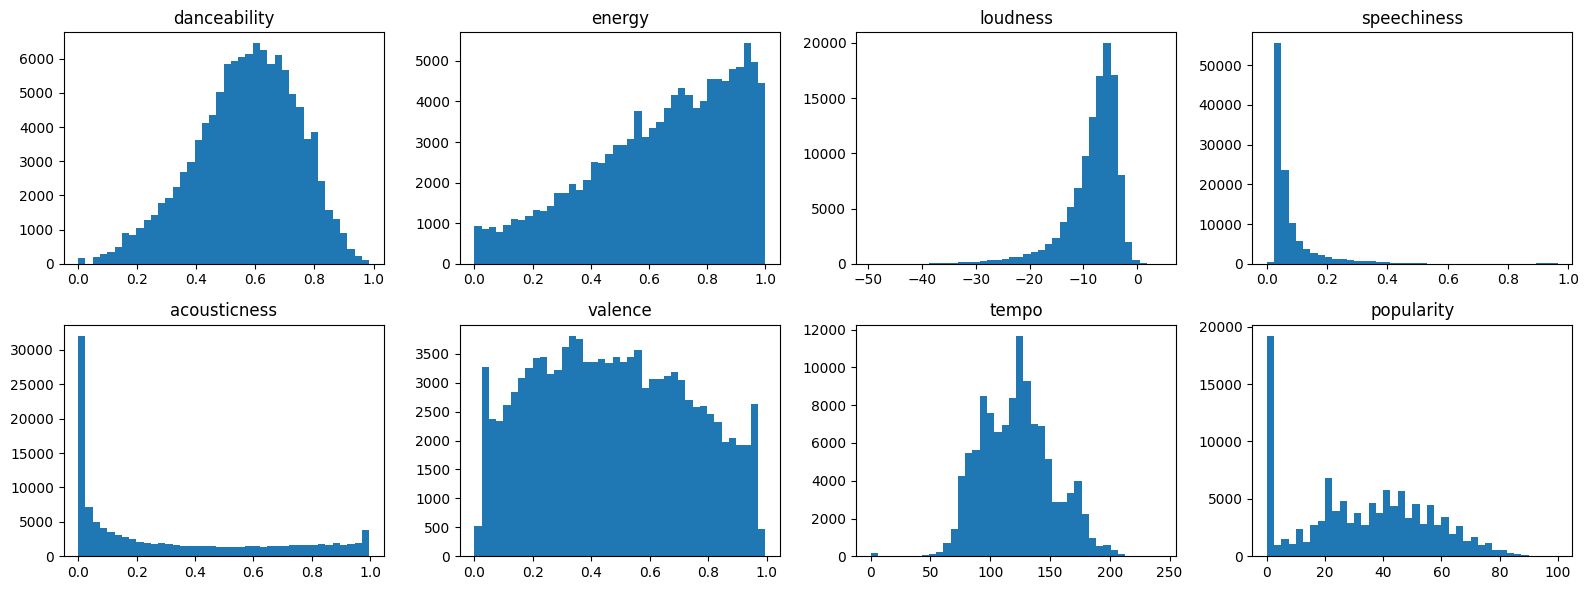

In [6]:
# Histogramas
features_num = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'valence', 'tempo', 'popularity']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, features_num):
    ax.hist(df[col], bins=40)
    ax.set_title(col)
plt.tight_layout()
plt.show()

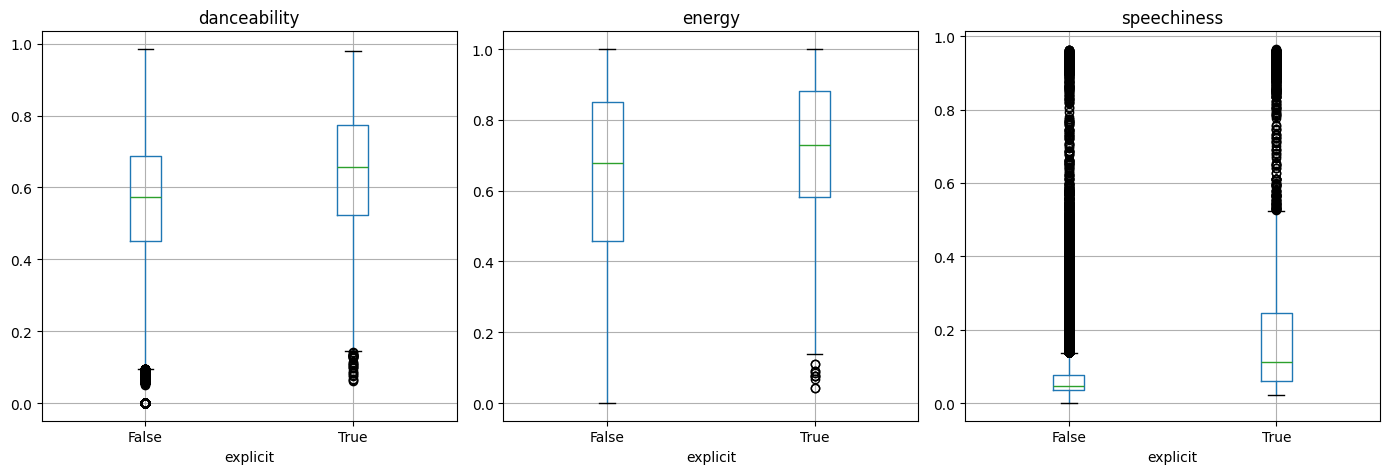

In [7]:
# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ['danceability', 'energy', 'speechiness']):
    df.boxplot(column=col, by='explicit', ax=ax)
    ax.set_title(col)
plt.suptitle('')
plt.tight_layout()
plt.show()

*Lo importante aqui es observar que speechiness tiene una distribucion notablemente diferente entre canciones explicitas y no explicitas. Esa diferencia es lo que el modelo va a aprender a explotar.*

## Sección 4

Define las features, convierte explicit a entero (0/1), haz el split con stratify=y y estandariza.

Pista: stratify=y es critico cuando las clases estan desbalanceadas. Asegura que el 8.5% de canciones explicitas quede representado tanto en train como en test en la misma proporcion.

### Preparación de datos (binaria)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
feature_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
                'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

X = df[feature_cols]
y = df['explicit'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

*Sin stratify, el split aleatorio podria dejar muy pocas muestras de la clase minoritaria en test y hacer que la evaluacion sea poco fiable.*

## Sección 5

Entrena LogisticRegression(max_iter=1000, random_state=42) y evalua con accuracy_score y classification_report.

Pista: classification_report imprime precision, recall y f1 por clase. Con clases desbalanceadas, el recall de la clase minoritaria es la metrica clave — no el accuracy global.

### Modelo binario

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [11]:
# Hace lo mismo que abajo, mirado en google

# 1. Instanciar el modelo
logreg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Entrenar (fit)
logreg.fit(X_train_sc, y_train)

# 3. Predecir y Evaluar
y_pred = logreg.predict(X_test_sc)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.914298245614035
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     20851
           1       0.49      0.09      0.16      1949

    accuracy                           0.91     22800
   macro avg       0.71      0.54      0.56     22800
weighted avg       0.88      0.91      0.89     22800



In [12]:
modelo_bin = LogisticRegression(max_iter=1000, random_state=42)
modelo_bin.fit(X_train_sc, y_train)
y_pred_bin = modelo_bin.predict(X_test_sc)

print('Accuracy:', round(accuracy_score(y_test, y_pred_bin), 4))
print(classification_report(y_test, y_pred_bin))

Accuracy: 0.9143
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     20851
           1       0.49      0.09      0.16      1949

    accuracy                           0.91     22800
   macro avg       0.71      0.54      0.56     22800
weighted avg       0.88      0.91      0.89     22800



*El accuracy es 0.9143 pero el recall de la clase 1 es solo 0.09. El modelo casi ignora las canciones explicitas porque aprendio que decir siempre "no explicita" ya le da un 91% de acierto. Eso es el problema del desbalance de clases.*

# Sección 6

Seccion 6 — Matriz de confusion (binaria)

Usa ConfusionMatrixDisplay para visualizar la matriz.

Pista: ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no explicit', 'explicit']).plot() genera el grafico directamente.

### Matriz de confusión (binaria)

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

[[20666   185]
 [ 1769   180]]


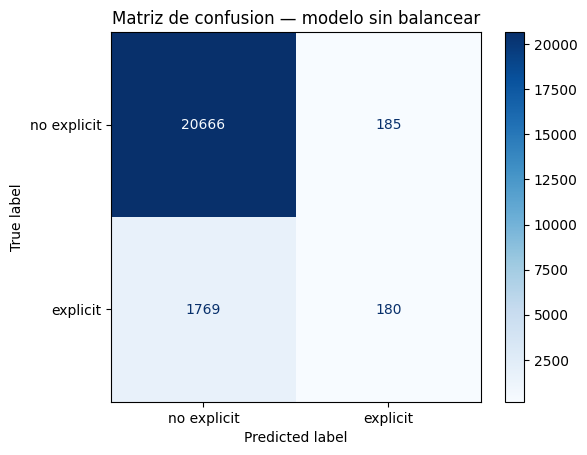

In [14]:
# Calcular la matriz
cm = confusion_matrix(y_test, y_pred_bin)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no explicit', 'explicit'])
disp.plot(cmap='Blues')
plt.title('Matriz de confusion — modelo sin balancear')
plt.show()

*La matriz muestra claramente el problema: 1,769 canciones explicitas clasificadas como no explicitas (falsos negativos) frente a solo 180 correctamente detectadas.*

## Sección 7

Seccion 7 — Modelo balanceado

Reentrena con class_weight='balanced' y compara los resultados con el modelo anterior.

Pista: class_weight='balanced' hace que sklearn calcule automaticamente pesos inversamente proporcionales a la frecuencia de cada clase. Las canciones explicitas reciben un peso ~10x mayor durante el entrenamiento.

### Modelo balanceado

In [15]:
modelo_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelo_bal.fit(X_train_sc, y_train)
y_pred_bal = modelo_bal.predict(X_test_sc)

print('Accuracy:', round(accuracy_score(y_test, y_pred_bal), 4))
print(classification_report(y_test, y_pred_bal))

Accuracy: 0.7391
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     20851
           1       0.21      0.72      0.32      1949

    accuracy                           0.74     22800
   macro avg       0.59      0.73      0.58     22800
weighted avg       0.90      0.74      0.79     22800



*El accuracy baja de 0.91 a 0.74, pero el recall de la clase 1 sube de 0.09 a 0.72. El modelo ahora detecta la mayoria de canciones explicitas a costa de generar mas falsos positivos. Cual es mejor depende del caso de uso: para un filtro parental, el recall alto importa mas.*

## Sección 8

Seccion 8 — Coeficientes del modelo

Crea un pd.Series con los coeficientes del modelo balanceado indexados por nombre de feature, ordenalo y graficalo.

Pista: los coeficientes estan en modelo_bal.coef_[0] (es un array 2D aunque haya una sola clase en regresion logistica binaria). Un coeficiente positivo aumenta la probabilidad de la clase 1 (explicit).

### Coeficientes del modelo

In [16]:
modelo_bal.coef_[0]

array([ 0.1700756 , -0.40865726,  0.4416629 ,  0.02350494,  0.42755493,
        0.81069483, -0.52237962, -0.37969884, -0.0844937 , -0.44541328,
       -0.02748105])

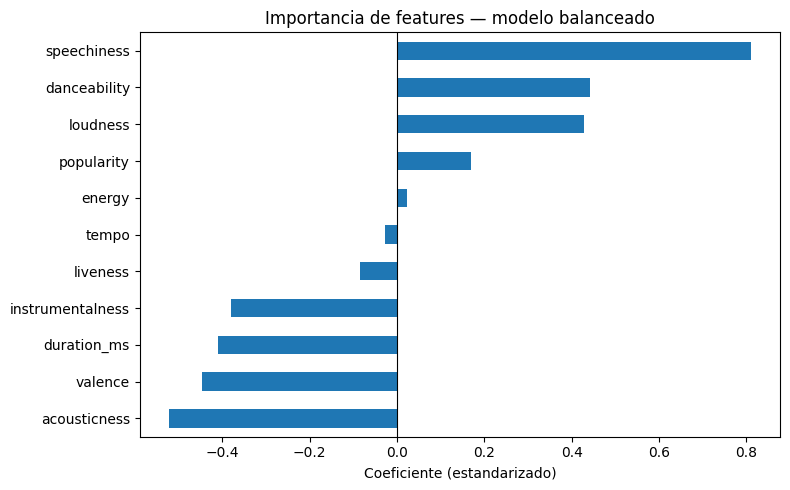

In [17]:
coefs = pd.Series(modelo_bal.coef_[0], index=feature_cols).sort_values()

coefs.plot(kind='barh', figsize=(8, 5))
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coeficiente (estandarizado)')
plt.title('Importancia de features — modelo balanceado')
plt.tight_layout()
plt.show()

*speechiness es el coeficiente mas alto porque las canciones con letra explicita tienden a ser rap o hip-hop, generos con alta densidad de palabras. acousticness es el mas negativo: las canciones acusticas raramente tienen contenido explicito.*

## Sección 9

Seccion 9 — Preparacion de datos (multiclase)

Filtra el dataframe a los 4 generos, haz el split con stratify=y y estandariza con un nuevo scaler.

Pista: usa df[df['track_genre'].isin(['pop', 'rock', 'hip-hop', 'classical'])] para filtrar. Los 4 generos tienen exactamente 1,000 canciones cada uno — el dataset esta perfectamente balanceado, no hace falta class_weight.

### Preparación de datos (multiclase)

In [30]:
generos = ['pop', 'rock', 'hip-hop', 'classical']
df_multi = df[df['track_genre'].isin(generos)].copy()

feature_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
                'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

X_m = df_multi[feature_cols]
y_m = df_multi['track_genre']

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42, stratify=y_m)

sc2 = StandardScaler()
X_tr_m_sc = sc2.fit_transform(X_tr_m)
X_te_m_sc = sc2.transform(X_te_m)

*Nota que se usa un StandardScaler nuevo, independiente del de la parte A. Nunca reutilices un scaler ajustado en datos distintos.*

In [31]:
df_multi.shape

(4000, 21)

In [32]:
df.shape

(113999, 21)

## Sección 10

Entrena LogisticRegression con los mismos parametros. Sklearn detecta automaticamente que hay mas de 2 clases.

Pista: no necesitas cambiar nada respecto al modelo binario. La regresion logistica multiclase (one-vs-rest por defecto) funciona con el mismo codigo.

### Modelo multiclase

In [33]:
modelo_mul = LogisticRegression(max_iter=1000, random_state=42)
modelo_mul.fit(X_tr_m_sc, y_tr_m)
y_pred_mul = modelo_mul.predict(X_te_m_sc)

print('Accuracy:', round(accuracy_score(y_te_m, y_pred_mul), 4))
print(classification_report(y_te_m, y_pred_mul))

Accuracy: 0.7075
              precision    recall  f1-score   support

   classical       0.93      0.93      0.93       200
     hip-hop       0.71      0.70      0.71       200
         pop       0.53      0.49      0.51       200
        rock       0.66      0.70      0.68       200

    accuracy                           0.71       800
   macro avg       0.71      0.71      0.71       800
weighted avg       0.71      0.71      0.71       800



*El accuracy es 0.7075. El baseline de adivinar al azar seria 0.25. El modelo casi triplica el baseline usando solo features de audio.*

## Sección 11

Pasa labels=generos a confusion_matrix para controlar el orden de las clases en la matriz.

Pista: con 4 clases la matriz es 4x4. La diagonal son los aciertos. Los valores fuera de la diagonal son errores — la fila indica la clase real y la columna la clase predicha.

### Matriz de confusión (multiclase)

[[ 99  43  47  11]
 [ 45 141  10   4]
 [ 33  26 141   0]
 [ 11   4   0 185]]


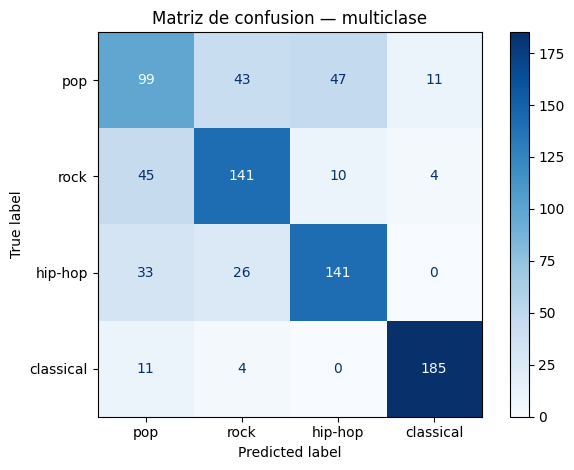

In [34]:
# Calcular la matriz
cm_m = confusion_matrix(y_te_m, y_pred_mul, labels=generos)
print(cm_m)

disp_m = ConfusionMatrixDisplay(confusion_matrix=cm_m, display_labels=generos)
disp_m.plot(cmap='Blues')
plt.title('Matriz de confusion — multiclase')
plt.tight_layout()
plt.show()

*La matriz muestra que classical casi nunca se confunde con otros generos (su audio es muy distintivo), mientras que pop se confunde frecuentemente con rock y con hip-hop porque el pop moderno toma elementos de ambos.*

### Conceptos clave

| Concepto | Donde se usa |
| :---: | :---: |
| stratify=y | Mantener la proporcion de clases en train y test |
| classification_report | Ver precision, recall y f1 por clase |
| Matriz de confusion | Identificar que errores comete el modelo y con que clases |
| class_weight='balanced' | Corregir el sesgo hacia la clase mayoritaria |
| Desbalance de clases | Cuando accuracy alto no implica modelo util |
| Baseline | Rendimiento de adivinar siempre la clase mayoritaria |
| Multiclase one-vs-rest | Como LogisticRegression extiende la clasificacion binaria a N clases |